csv mean - comma separated values...
here we are keeping this in a dataframe
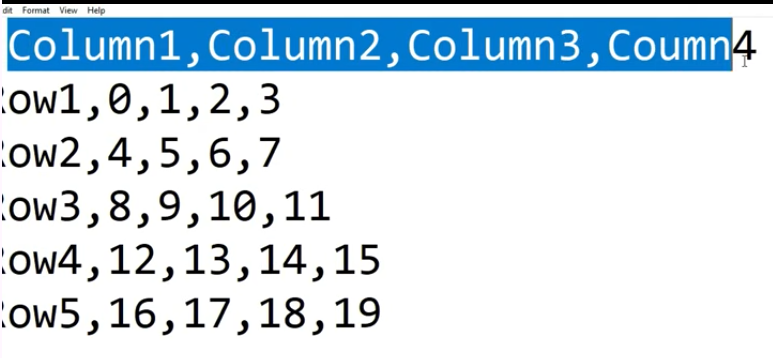
this is how csv files will be like..

DataFrame
   |
   |-- df['col'] ----------> Series
   |                             |
   |                             |-- value_counts()
   |                             |-- values
   |
   |-- df.values ----------> whole DataFrame as ndarray

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('customers-100.csv')# to read csv file
df.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,DD37Cf93aecA6Dc,Sheryl,Baxter,Rasmussen Group,East Leonard,Chile,229.077.5154,397.884.0519x718,zunigavanessa@smith.info,2020-08-24,http://www.stephenson.com/
1,2,1Ef7b82A4CAAD10,Preston,Lozano,Vega-Gentry,East Jimmychester,Djibouti,5153435776,686-620-1820x944,vmata@colon.com,2021-04-23,http://www.hobbs.com/
2,3,6F94879bDAfE5a6,Roy,Berry,Murillo-Perry,Isabelborough,Antigua and Barbuda,+1-539-402-0259,(496)978-3969x58947,beckycarr@hogan.com,2020-03-25,http://www.lawrence.com/
3,4,5Cef8BFA16c5e3c,Linda,Olsen,"Dominguez, Mcmillan and Donovan",Bensonview,Dominican Republic,001-808-617-6467x12895,+1-813-324-8756,stanleyblackwell@benson.org,2020-06-02,http://www.good-lyons.com/
4,5,053d585Ab6b3159,Joanna,Bender,"Martin, Lang and Andrade",West Priscilla,Slovakia (Slovak Republic),001-234-203-0635x76146,001-199-446-3860x3486,colinalvarado@miles.net,2021-04-17,https://goodwin-ingram.com/


In [8]:
df.info()#how many columns,integer values etc..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Index              100 non-null    int64 
 1   Customer Id        100 non-null    object
 2   First Name         100 non-null    object
 3   Last Name          100 non-null    object
 4   Company            100 non-null    object
 5   City               100 non-null    object
 6   Country            100 non-null    object
 7   Phone 1            100 non-null    object
 8   Phone 2            100 non-null    object
 9   Email              100 non-null    object
 10  Subscription Date  100 non-null    object
 11  Website            100 non-null    object
dtypes: int64(1), object(11)
memory usage: 9.5+ KB


In [9]:
df.describe()#object info won't be considered in describe
#i.e; catagerical values

,Index
count,100.000000
mean,50.500000
std,29.011492
min,1.000000
25%,25.750000
50%,50.500000
75%,75.250000
max,100.000000


what if in a csv file,the file is separated by symbol ";" instead of ","(comma)
let, test_1.csv be the values separated by ;

In [14]:
test_df = pd.read_csv('test_1.csv',sep=';')
test_df.head()

,column1,column2,column3,column4
row1,0,1,2,3
row2,4,5,6,7
row3,8,9,10,11
row4,12,13,14,15


In [16]:
test_df.iloc[:,:]

,column1,column2,column3,column4
row1,0,1,2,3
row2,4,5,6,7
row3,8,9,10,11
row4,12,13,14,15


In [18]:
test_df['column1'].value_counts()

column1
0     1
4     1
8     1
12    1
Name: count, dtype: int64

In [20]:
#test_df['row1'].value_counts()#won't work for rows

In [21]:
#create a dataframe to know the desired values
test_df[test_df['column1']>4]

,column1,column2,column3,column4
row3,8,9,10,11
row4,12,13,14,15


In [26]:
from io import StringIO, BytesIO

In [22]:
#creating a csv file
data = ('c1,c2,c3,c4\n'
               '1,2,3,4\n'
                '5,6,7,8\n'
                 '9,10,11,12')

In [31]:
print(data)
print(type(data))

c1,c2,c3,c4
1,2,3,4
5,6,7,8
9,10,11,12
<class 'str'>


In [27]:
StringIO() #

In [30]:
new_df = pd.read_csv(StringIO(data)) # help to be in the dataframe
new_df.head()

,c1,c2,c3,c4
0,1,2,3,4
1,5,6,7,8
2,9,10,11,12


In [36]:
new_df = pd.read_csv(StringIO(data),usecols=['c1','c2']) #to read specific cols
new_df
new_df.describe()

,c1,c2
count,3.0,3.0
mean,5.0,6.0
std,4.0,4.0
min,1.0,2.0
25%,3.0,4.0
50%,5.0,6.0
75%,7.0,8.0
max,9.0,10.0


In [34]:
# to convert to csv file
new_df.to_csv('data.csv')

In [47]:
new_df = pd.read_csv(StringIO(data),dtype = object)
new_df

,c1,c2,c3,c4
0,1,2,3,4
1,5,6,7,8
2,9,10,11,12


In [48]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   c1      3 non-null      object
 1   c2      3 non-null      object
 2   c3      3 non-null      object
 3   c4      3 non-null      object
dtypes: object(4)
memory usage: 228.0+ bytes


In [49]:
new_df['c1'][0]

'1'

In [50]:
new_df = pd.read_csv(StringIO(data),dtype = int)#will change all columns into 'dtype datatype'
new_df

,c1,c2,c3,c4
0,1,2,3,4
1,5,6,7,8
2,9,10,11,12


In [51]:
new_df['c1'][0]

np.int64(1)

In [52]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c1      3 non-null      int64
 1   c2      3 non-null      int64
 2   c3      3 non-null      int64
 3   c4      3 non-null      int64
dtypes: int64(4)
memory usage: 228.0 bytes


In [53]:
#keep different different values for each columns
new_a1 = pd.read_csv(StringIO(data),dtype={'c1':int,'c2':object,'c3':float})

In [54]:
new_a1

,c1,c2,c3,c4
0,1,2,3.0,4
1,5,6,7.0,8
2,9,10,11.0,12


In [63]:
#how to use index_col
data2 = ('a,b,c,d\n'
             '1,pavan,3,4\n'
              '8,sai,6,7')

In [64]:
data2

'a,b,c,d \n1,pavan,3,4\n8,sai,6,7'

In [66]:
pd.read_csv(StringIO(data2),index_col=1)

,a,c,d
b,,,
pavan,1,3,4
sai,8,6,7


In [67]:
pd.read_csv(StringIO(data2),index_col=0)

,b,c,d
a,,,
1,pavan,3,4
8,sai,6,7


In [68]:
pd.read_csv(StringIO(data2))

,a,b,c,d
0,1,pavan,3,4
1,8,sai,6,7


In [75]:
#how to use index_col
data3 = ('a,b,c\n'
             '1,pavan,kan\n'
              '8,sai,sai')

In [76]:
pd.read_csv(StringIO(data3))

,a,b,c
0,1,pavan,kan
1,8,sai,sai


In [84]:
#what if i keep commas
data4 = ('a,b,c,\n'
            '1,pavan,kan,\n'
            '8,sai,sai,')

In [85]:
pd.read_csv(StringIO(data4))

,a,b,c,Unnamed: 3
0,1,pavan,kan,NaN
1,8,sai,sai,NaN


in the above we used , therefore in csv, it will be counted like that extra value

In [86]:
pd.read_csv(StringIO(data4),index_col=False)# now don'ty consider this

,a,b,c,Unnamed: 3
0,1,pavan,kan,NaN
1,8,sai,sai,NaN
